In [17]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from tsfm_public import (
    TimeSeriesForecastingPipeline,
    TimeSeriesPreprocessor,
    TinyTimeMixerForPrediction,
)

In [18]:
CSV_PATH = "data/FEDFUNDS.csv"   # change this
DATE_COL = "observation_date"            # change this
TARGET_COL = "FEDFUNDS"             # change this

df = pd.read_csv(CSV_PATH, parse_dates=[DATE_COL])

df = (
    df[[DATE_COL, TARGET_COL]]
    .dropna()
    .sort_values(DATE_COL)
    .reset_index(drop=True)
)

df.head(), df.tail(), len(df)

(  observation_date  FEDFUNDS
 0       1954-07-01      0.80
 1       1954-08-01      1.22
 2       1954-09-01      1.07
 3       1954-10-01      0.85
 4       1954-11-01      0.83,
     observation_date  FEDFUNDS
 856       2025-11-01      3.88
 857       2025-12-01      3.72
 858       2026-01-01      3.64
 859       2026-02-01      3.64
 860       2026-03-01      3.64,
 861)

In [19]:
context_length = 10
prediction_length = 96

assert len(df) >= context_length, f"Need at least {context_length} observations."

context_df = df.tail(context_length).copy()

device = (
    "mps"
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
    else "cpu"
)

tsp = TimeSeriesPreprocessor(
    timestamp_column=DATE_COL,
    target_columns=[TARGET_COL],
    context_length=context_length,
    prediction_length=prediction_length,
    scaling=True,
    encode_categorical=False,
    scaler_type="standard",
)

tsp = tsp.train(context_df)

model = TinyTimeMixerForPrediction.from_pretrained(
    "ibm-granite/granite-timeseries-ttm-r2",
    revision="512-96-ft-r2.1",
    num_input_channels=tsp.num_input_channels,
)

pipeline = TimeSeriesForecastingPipeline(
    model,
    device=device,
    feature_extractor=tsp,
    batch_size=1,
    add_known_ground_truth=False,
)

forecast_df = pipeline(context_df)
forecast_df.head()

Device set to use mps
INFO:p-70138:t-8705831168:time_series_forecasting_pipeline.py:preprocess:Preprocessing with: {'prediction_length': 96, 'context_length': 512, 'frequency_token': 0, 'id_columns': [], 'timestamp_column': 'observation_date', 'target_columns': ['FEDFUNDS'], 'observable_columns': [], 'control_columns': [], 'conditional_columns': [], 'categorical_columns': [], 'static_categorical_columns': []}


,observation_date,FEDFUNDS
0,2026-03-01,"[3.7285241191801894, 3.758588267200177, 3.7725..."


In [20]:
pred_col = f"{TARGET_COL}_prediction" if f"{TARGET_COL}_prediction" in forecast_df.columns else TARGET_COL

# Usually the final row is the forecast from the latest available context window
pred_values = np.asarray(forecast_df.iloc[-1][pred_col], dtype=float)

freq = pd.infer_freq(df[DATE_COL].tail(100))

if freq is None:
    freq = "D"   # change to "B", "W", "H", etc. if needed

future_dates = pd.date_range(
    start=df[DATE_COL].iloc[-1],
    periods=prediction_length + 1,
    freq=freq,
)[1:]

forecast_out = pd.DataFrame({
    DATE_COL: future_dates,
    "ttm_forecast": pred_values,
})

forecast_out.head()

,observation_date,ttm_forecast
0,2026-04-01,3.728524
1,2026-05-01,3.758588
2,2026-06-01,3.772580
3,2026-07-01,3.781721
4,2026-08-01,3.788400


In [21]:
next_forecast = forecast_out.iloc[0]
next_forecast

observation_date    2026-04-01 00:00:00
ttm_forecast                   3.728524
Name: 0, dtype: object

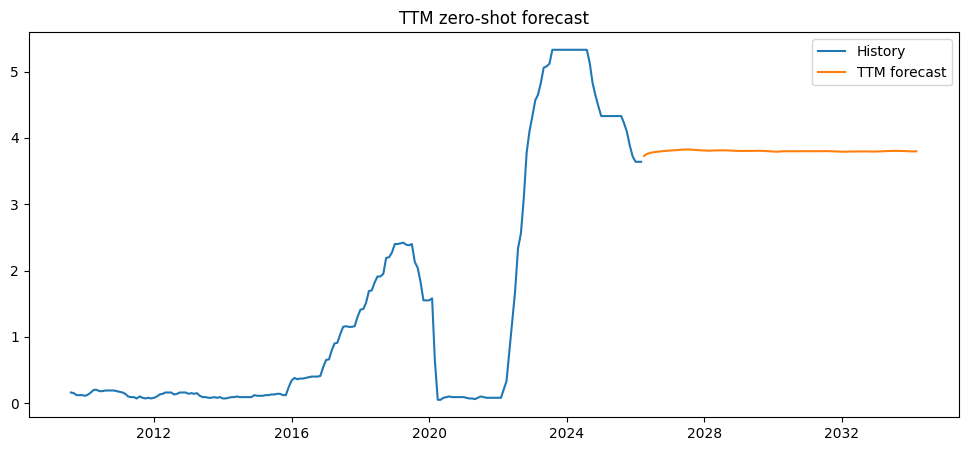

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(df[DATE_COL].tail(200), df[TARGET_COL].tail(200), label="History")
plt.plot(forecast_out[DATE_COL], forecast_out["ttm_forecast"], label="TTM forecast")

plt.title("TTM zero-shot forecast")
plt.legend()
plt.show()